# **CUSTOMER SEGMENTATION PROJECT**

Use a customer dataset to group customers into different
segments based on their purchasing behaviour. Apply clustering
techniques like K-Means to identify patterns and describe the
characteristics of each segment. Pre-process the data, perform
clustering, and visualize the results.

## **Importing Libraries:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading Dataset:**

In [66]:
df= pd.read_csv('Test.csv')

In [3]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 205.4+ KB


In [5]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1'],
      dtype='object')

## **Defining Columns:**

1. ID = Identification number of each customer.

2. Gender = Defines about the gender , either male or female.
3. Ever_Married = Is the customer married or not .
4. Age = Telling the age of customer
5. Graduated = Is the customer graduated or not.
6. Profession = Defining about the job profession.
7. Work_Experience = Telling about the experience of job / work.
8. Spending_Score = What are the spendings of customer.
9. Family_Size = Members of family.
10. Var_1 = It is an anonymized categorical feature provided in the dataset.

In [6]:
df.shape

(2627, 10)

In [7]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2358.000000,2514.000000
mean,463433.918919,43.649791,2.552587,2.825378
std,2618.245698,16.967015,3.341094,1.551906
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,4.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [8]:
df.dtypes

ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
dtype: object

In [9]:
df['Spending_Score'].head()

0        Low
1    Average
2        Low
3       High
4        Low
Name: Spending_Score, dtype: object

In [67]:
df.isna().sum()

ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64

There are 6 null values attributes inside the dataset . They will be sorted one by one.

## **Handling Null Values:**

### 1. Ever_Married:

In [68]:
df['Ever_Married'].value_counts()

Ever_Married
Yes    1520
No     1057
Name: count, dtype: int64

In [69]:
df['Ever_Married'].isnull().sum()

np.int64(50)

In [ ]:
df['Ever_Married'].fillna(df['Ever_Married'].mode()[0], inplace=True)
df['Ever_Married'].isnull().sum()

### 2. Graduated:

In [71]:
df['Graduated'].value_counts()

Graduated
Yes    1602
No     1001
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Graduated')

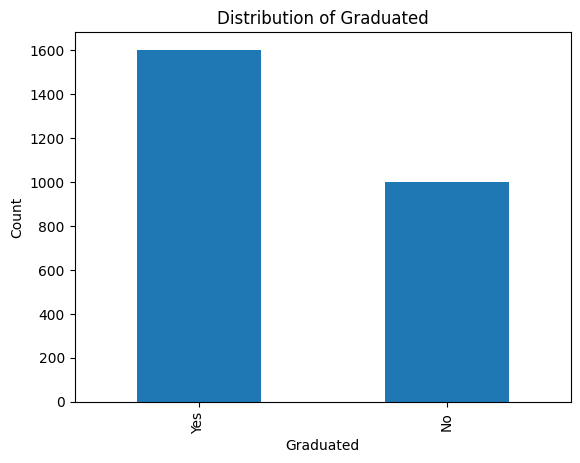

In [72]:
df['Graduated'].value_counts().plot(kind='bar')
plt.xlabel('Graduated')
plt.ylabel('Count')
plt.title('Distribution of Graduated')

In [73]:
df['Graduated'].isna().sum()

np.int64(24)

In [ ]:
df['Graduated'].fillna(df['Graduated'].mode()[0] , inplace=True)
df['Graduated'].isna().sum()

### 3. Profession:

In [75]:
df['Profession'].value_counts()

Profession
Artist           802
Healthcare       418
Entertainment    301
Doctor           242
Engineer         236
Lawyer           221
Executive        176
Marketing        111
Homemaker         82
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Profession')

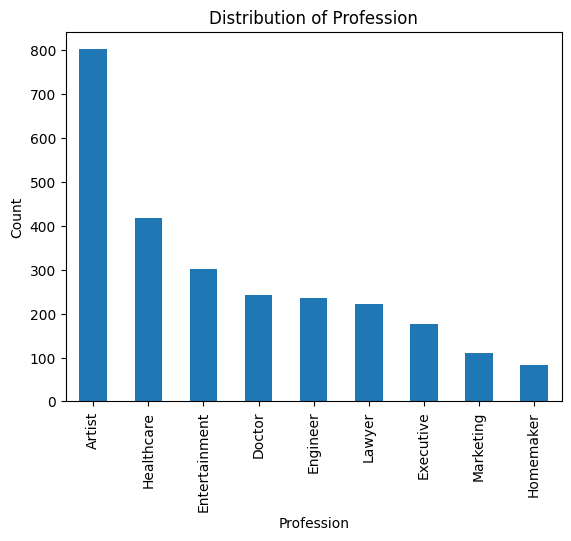

In [76]:
df['Profession'].value_counts().plot(kind='bar')
plt.xlabel('Profession')
plt.ylabel('Count')
plt.title('Distribution of Profession')

In [77]:
df['Profession'].isna().sum()

np.int64(38)

In [ ]:
df['Profession'].fillna(df['Profession'].mode()[0] , inplace=True)
df['Profession'].isna().sum()

### 4. Work_Experience:

In [79]:
df['Work_Experience'].value_counts()

Work_Experience
1.0     773
0.0     769
8.0     149
9.0     139
4.0      93
2.0      87
3.0      82
5.0      76
6.0      61
7.0      60
14.0     21
11.0     14
12.0     12
10.0     11
13.0     11
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Work Experience')

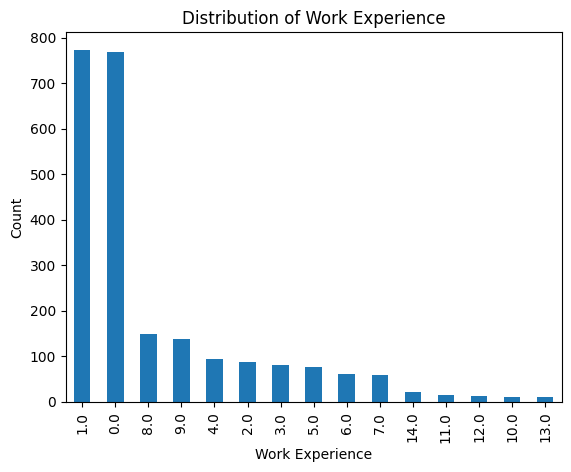

In [80]:
df['Work_Experience'].value_counts().plot(kind='bar')
plt.xlabel('Work Experience')
plt.ylabel('Count')
plt.title('Distribution of Work Experience')

In [24]:
df['Work_Experience'].unique()

array([ 0.,  8., 11., nan,  5.,  1.,  2.,  9.,  3.,  6.,  7.,  4., 13.,
       10., 12., 14.])

In [25]:
df['Work_Experience'].isna().sum()

np.int64(269)

In [ ]:
df['Work_Experience'].fillna(df['Work_Experience'].mean() , inplace=True)


In [27]:
df['Work_Experience'].isna().sum()

np.int64(0)

### 5. Family_Size:

In [28]:
df['Family_Size'].value_counts()

Family_Size
2.0    768
1.0    512
3.0    455
4.0    444
5.0    200
6.0     78
7.0     26
9.0     16
8.0     15
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Family Size')

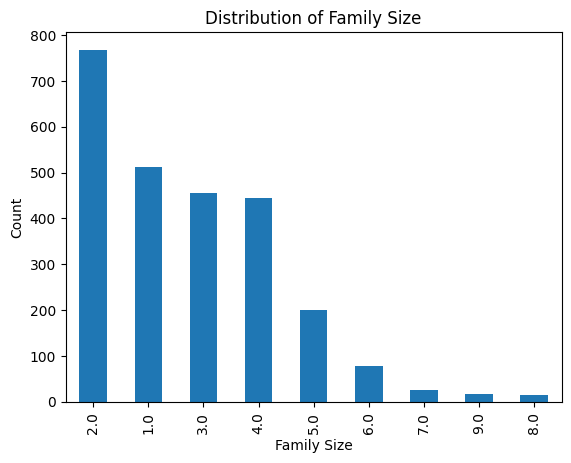

In [29]:
df['Family_Size'].value_counts().plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.title('Distribution of Family Size')

In [30]:
df['Family_Size'].nunique()

9

In [31]:
df['Family_Size'].isna().sum()

np.int64(113)

In [ ]:
df['Family_Size'].fillna(df['Family_Size'].mean(), inplace=True)

In [33]:
df['Family_Size'].isna().sum()

np.int64(0)

### 7. Var_1:

In [34]:
df['Var_1'].value_counts()

Var_1
Cat_6    1672
Cat_4     386
Cat_3     267
Cat_2     141
Cat_7      66
Cat_1      34
Cat_5      29
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Var_1')

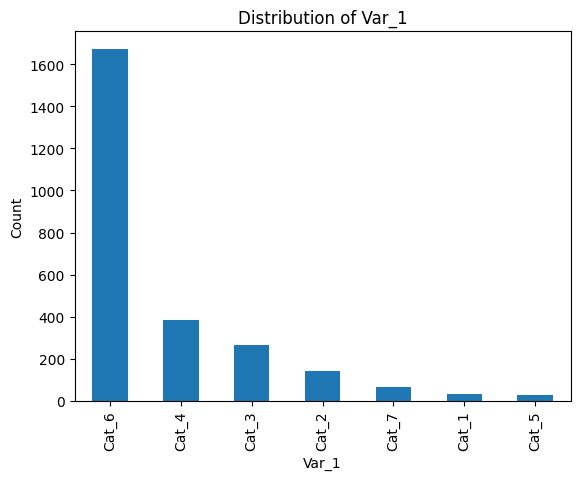

In [35]:
df['Var_1'].value_counts().plot(kind='bar')
plt.xlabel('Var_1')
plt.ylabel('Count')
plt.title('Distribution of Var_1')

In [36]:
df['Var_1'].isna().sum()

np.int64(32)

In [ ]:
df['Var_1'].fillna(df['Var_1'].mode()[0] , inplace=True)
df['Var_1'].isna().sum()

In [38]:
df['Var_1'].isna().sum()

np.int64(0)

In [39]:
df.isnull().sum()

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64

## **Duplicate Values:**

In [40]:
df.duplicated().sum()

np.int64(0)

# **Insights of the Data:**

In [41]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1'],
      dtype='object')

## 1. **How many Married and Unmarried people are there?**

Text(0.5, 1.0, 'Distribution of Ever Married')

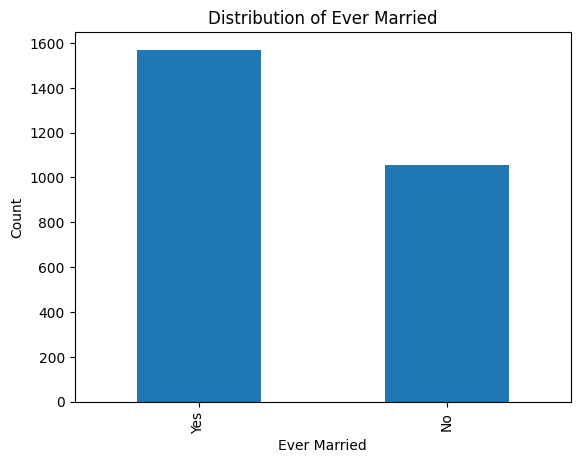

In [42]:
df['Ever_Married'].value_counts().plot(kind='bar')
plt.xlabel('Ever Married')
plt.ylabel('Count')
plt.title('Distribution of Ever Married')

>The bar chart shows the distribution of marital status in the dataset. There are 1,520 married and 1,057 unmarried customers, meaning the majority of customers in this dataset are married.


## 2. **How many males and females are there?**

In [43]:
df['Gender'].value_counts()

Gender
Male      1424
Female    1203
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Gender')

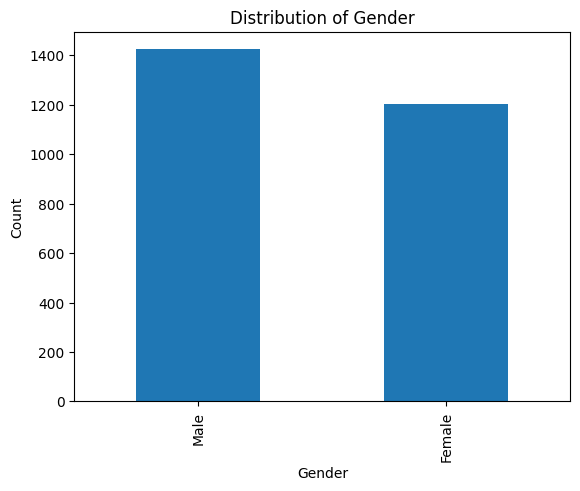

In [44]:
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')     
plt.title('Distribution of Gender')

> The bar chart shows gender distribution. The dataset contains 1,424 males and 1,203 females, indicating a slightly male-dominant dataset but with a fairly balanced gender ratio overall.

## 3. **Who spends the most among males and females?**

In [45]:
pd.crosstab(df['Gender'] , df['Spending_Score'])

Spending_Score,Average,High,Low
Gender,,,
Female,272,159,772
Male,353,227,844


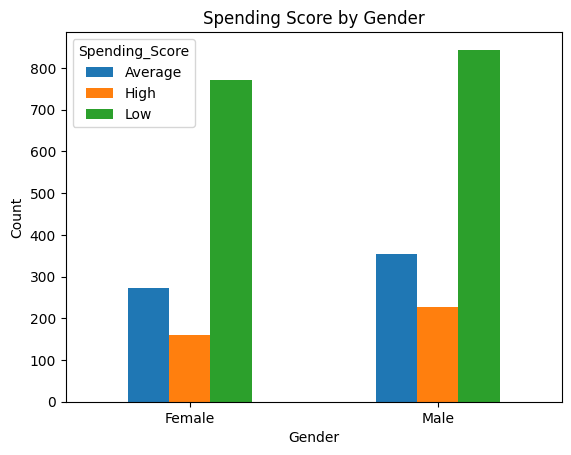

In [104]:
pd.crosstab(df['Gender'] , df['Spending_Score']).plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Spending Score by Gender')
plt.xticks(rotation=0)  
plt.show()

> The grouped bar chart (crosstab) shows spending scores by gender. Males spend the most across all three spending categories — Low, Average, and High — compared to females.

## 4. **How many Graduated and Non graduated males and females are there?**

In [47]:
pd.crosstab(df['Gender'], df['Graduated'])

Graduated,No,Yes
Gender,,
Female,423,780
Male,578,846


Text(0.5, 1.0, 'Distribution of Graduated by Gender')

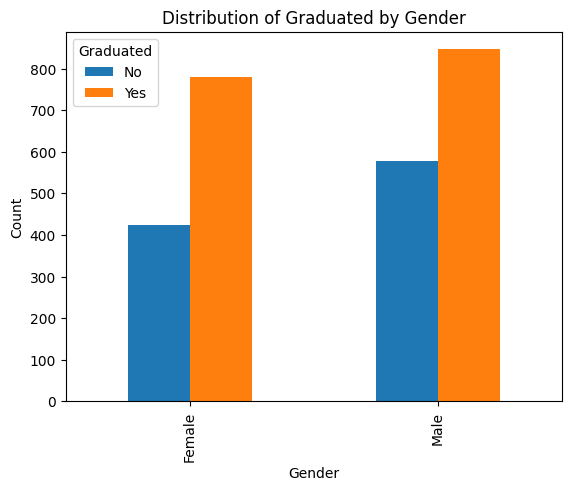

In [48]:
pd.crosstab(df['Gender'], df['Graduated']).plot(kind='bar') 
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Graduated by Gender')

> The crosstab bar chart shows that males are higher in both graduated and non-graduated categories compared to females, simply because there are more males in the dataset overall.

## 5. **Which age category spends the most?**

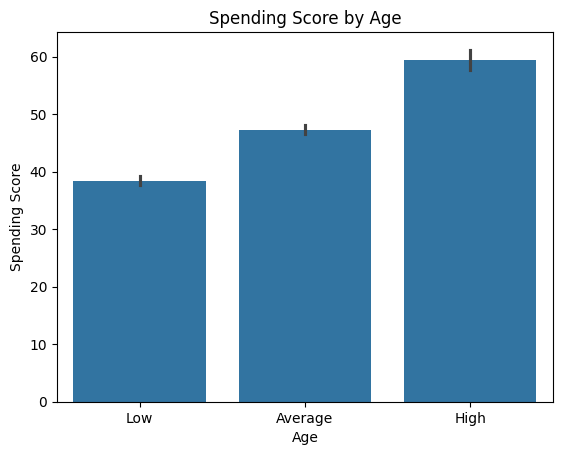

In [103]:
sns.barplot(x='Spending_Score',y='Age', data=df)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Spending Score by Age')
plt.show()

> The bar plot shows that people between 40 to 60 years have the highest spending. Customers below 40 tend to spend the least, while those between 40 to 50 fall in the average spending category.

## 6. **What are the professions of graduated vs non graduated people?**

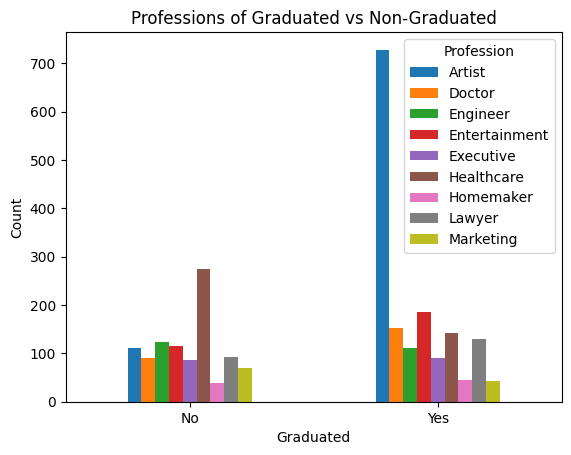

In [101]:
pd.crosstab(df['Graduated'], df['Profession']).plot(kind='bar')
plt.xlabel('Graduated')
plt.ylabel('Count')
plt.title('Professions of Graduated vs Non-Graduated')
plt.xticks(rotation=0)
plt.show()

> The bar chart compares professions of graduated (Yes) and non-graduated (No) customers. Among graduated customers, Artists are by far the most dominant profession, with over 700 count, followed by Entertainment and Healthcare. Among non-graduated customers, Healthcare professionals are the most common, followed by Engineer and Entertainment. Overall, graduation is most strongly associated with the Artist profession in this dataset.

## 7. **Who are the most experienced people ?**

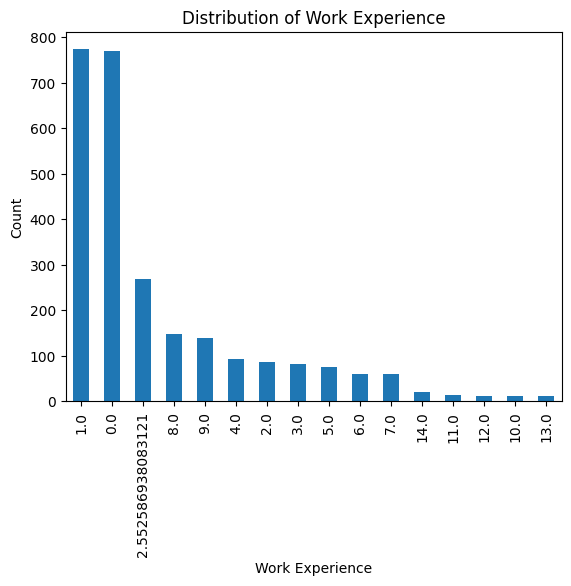

In [105]:
df['Work_Experience'].value_counts().plot(kind='bar')
plt.xlabel('Work Experience')
plt.ylabel('Count')
plt.title('Distribution of Work Experience')
plt.show()

> The bar chart shows that most customers have only 0 to 1 year of work experience, meaning the dataset is dominated by fresher or early-career customers.

## 8. **According to the profession how much work experience people have?**

Text(0.5, 1.0, 'Average Work Experience by Profession')

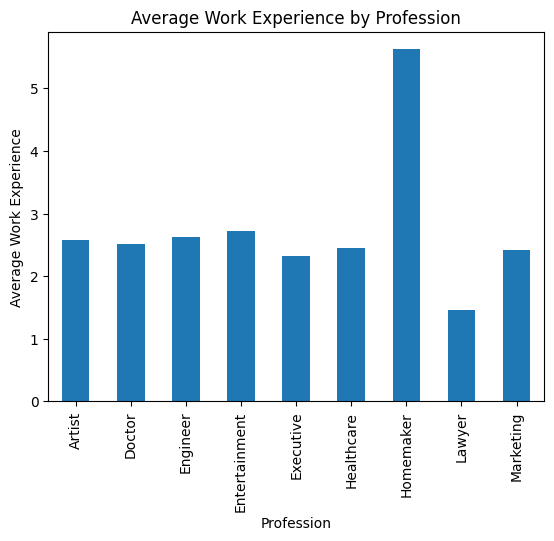

In [52]:
df.groupby('Profession')['Work_Experience'].mean().plot(kind='bar')
plt.xlabel('Profession')
plt.ylabel('Average Work Experience')
plt.title('Average Work Experience by Profession')

> The grouped bar chart shows average work experience by profession. Homemakers have the most work experience on average compared to other professions like Artist, Lawyer, or Healthcare.

# **Model Development:**

In [84]:
df.drop(['ID', 'Var_1'], axis=1, inplace=True)

In [85]:
df.dtypes

Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
dtype: object

In [86]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
OHE = ColumnTransformer([('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'), ['Gender', 'Ever_Married',
 'Graduated', 'Profession', 'Spending_Score'])] , remainder='passthrough')

In [87]:
df_encoded = OHE.fit_transform(df)

In [88]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_scaled = scalar.fit_transform(df_encoded)

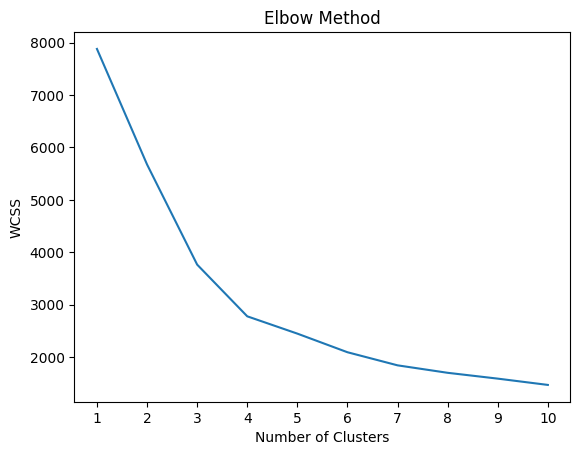

In [106]:
from sklearn.cluster import KMeans

numeric_cols = df[['Age', 'Work_Experience', 'Family_Size']]
scaler2 = StandardScaler()
X_num = scaler2.fit_transform(numeric_cols)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_num)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

"Elbow Method was applied on numeric features (Age, Work Experience, Family Size) to clearly identify the optimal number of clusters. The final KMeans model was trained on all features for comprehensive customer segmentation."

In [92]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [93]:
print(df['Cluster'].value_counts())

Cluster
2    992
0    913
3    421
1    301
Name: count, dtype: int64


In [94]:
df.groupby('Cluster').agg({
    'Age': 'mean',
    'Work_Experience': 'mean',
    'Family_Size': 'mean',
    'Gender': lambda x: x.mode()[0],
    'Ever_Married': lambda x: x.mode()[0],
    'Graduated': lambda x: x.mode()[0],
    'Profession': lambda x: x.mode()[0],
    'Spending_Score': lambda x: x.mode()[0]
}).round(2)

,Age,Work_Experience,Family_Size,Gender,Ever_Married,Graduated,Profession,Spending_Score
Cluster,,,,,,,,
0,47.73,2.37,2.68,Female,Yes,Yes,Artist,Average
1,42.75,2.72,2.72,Male,Yes,Yes,Entertainment,Low
2,30.98,2.99,3.05,Female,No,No,Healthcare,Low
3,65.28,1.81,2.67,Male,Yes,Yes,Lawyer,High


## **Cluster Analysis Interpretation:**

Cluster 0 — Middle-aged Female Artists (Average Spenders)
This group consists of married, graduated females around the age of 47 working as Artists. They have moderate spending habits, making them a stable mid-range target market.


Cluster 1 — Mature Males in Entertainment (Low Spenders)
This group includes married, graduated males around the age of 42 working in Entertainment. Despite being experienced professionals, they tend to spend less, possibly saving more.


Cluster 2 — Young Unmarried Females in Healthcare (Low Spenders)
This is the youngest group with an average age of 30. They are unmarried, non-graduated females working in Healthcare with low spending, likely due to early career stage and lower income.


Cluster 3 — Senior Married Male Lawyers (High Spenders) 
This is the most valuable customer segment. They are older males around 65, married, graduated, and working as Lawyers with the highest spending score. Businesses should prioritize this group for premium products and services.

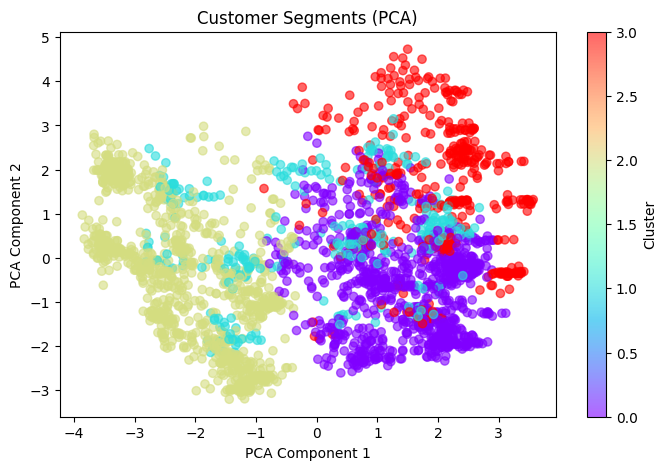

In [97]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], 
            c=df['Cluster'], cmap='rainbow', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA)')
plt.colorbar(label='Cluster')
plt.show()

# **Overall Conclusion**
This project aimed to segment customers based on their demographic and behavioral data using the K-Means clustering algorithm.
> **Data Preprocessing:**
The dataset contained missing values in multiple columns which were handled by filling categorical columns with mode and numerical columns with mean. Duplicate values were also checked and confirmed to be absent.

> **Exploratory Data Analysis:**
The EDA revealed several key insights. The dataset is slightly male-dominant with more married customers than unmarried. Males spend more across all spending categories. Most customers have 0 to 1 year of work experience, and people between the ages of 40 to 60 tend to spend the most.

> **Model Development:**
OneHotEncoding was applied to convert categorical features into numerical format. StandardScaler was used to normalize all features so that no single column dominates the model. The Elbow Method was applied on numeric features to determine the optimal number of clusters, which was found to be k = 4.

> **Clustering Results:**
KMeans successfully divided customers into 4 distinct segments:

Cluster 0 → Middle-aged Female Artists with Average Spending\
Cluster 1 → Mature Males in Entertainment with Low Spending\
Cluster 2 → Young Unmarried Females in Healthcare with Low Spending\
Cluster 3 → Senior Married Male Lawyers with High Spending

> **Visualization:**
PCA was used to reduce the high-dimensional data into 2 components for visualization. The scatter plot clearly showed 4 distinct customer groups, confirming that the clustering model performed well.

### **Final Takeaway:**
This segmentation can help businesses target each customer group with personalized marketing strategies — for example, offering premium products to Cluster 3 (high spenders) and budget-friendly options to Cluster 1 and 2 (low spenders).